# Bodrum Hotel & Destination Intelligence
## 17 - Trip.com Customer Voice & Guest Segment Analysis

In [1]:

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\tripcom_customer_voice"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)

clean = pd.read_csv(REPO_ROOT + r"\data\processed\tripcom_reviews_clean.csv")
print("rows:", len(clean), "hotels:", clean['hotel_id'].nunique())


rows: 3013 hotels: 94


## D1: Overall KPI

In [2]:

kpi = {
    "total_reviews": len(clean),
    "hotel_count": clean["hotel_id"].nunique(),
    "mean_rating_5": round(clean["rating_5_scale"].mean(), 2),
    "median_rating_5": clean["rating_5_scale"].median(),
    "low_share_pct": round((clean["rating_group"]=="LOW").mean()*100, 1),
    "high_share_pct": round((clean["rating_group"]=="HIGH").mean()*100, 1),
    "traveler_type_coverage_pct": round((clean["traveler_type"]!="UNKNOWN").mean()*100, 1),
    "room_type_coverage_pct": round((clean["room_type"]!="UNKNOWN").mean()*100, 1),
    "stay_date_coverage_pct": round(clean["stay_year"].notna().mean()*100, 1),
    "reviewer_location_coverage_pct": round(clean["reviewer_country"].notna().mean()*100, 1),
}
for k, v in kpi.items():
    print(f"{k}: {v}")


total_reviews: 3013
hotel_count: 94
mean_rating_5: 4.38
median_rating_5: 5.0
low_share_pct: 9.8
high_share_pct: 83.2
traveler_type_coverage_pct: 51.3
room_type_coverage_pct: 11.0
stay_date_coverage_pct: 97.9
reviewer_location_coverage_pct: 11.6


## D2: Hotel rating summary

In [3]:

def support_tier(n):
    if n < 5: return "VERY_LOW_SUPPORT"
    if n < 20: return "LOW_SUPPORT"
    if n < 50: return "MODERATE"
    return "STRONGER"

hotel_rating = clean.groupby(["hotel_id","hotel_name","area"]).agg(
    n=("rating_5_scale","count"), mean_rating_5=("rating_5_scale","mean"),
    median_rating_5=("rating_5_scale","median"), std=("rating_5_scale","std"),
).reset_index()
low = clean[clean["rating_group"]=="LOW"].groupby("hotel_id").size()
mid = clean[clean["rating_group"]=="MID"].groupby("hotel_id").size()
high = clean[clean["rating_group"]=="HIGH"].groupby("hotel_id").size()
hotel_rating = hotel_rating.set_index("hotel_id")
hotel_rating["low_share"] = (low/hotel_rating["n"]).fillna(0).round(3)
hotel_rating["mid_share"] = (mid/hotel_rating["n"]).fillna(0).round(3)
hotel_rating["high_share"] = (high/hotel_rating["n"]).fillna(0).round(3)
hotel_rating["sample_support"] = hotel_rating["n"].apply(support_tier)
hotel_rating = hotel_rating.reset_index()
hotel_rating.sort_values("n", ascending=False)


,hotel_id,hotel_name,area,n,mean_rating_5,median_rating_5,std,low_share,mid_share,high_share,sample_support
20,BOD043,METT Hotel & Beach Resort Bodrum,Bodrum Merkez,90,4.588889,5.0,0.827300,0.022,0.089,0.889,STRONGER
30,BOD064,Jasmin Elite Residence & Spa,Gümbet,88,4.573864,5.0,0.834906,0.045,0.068,0.886,STRONGER
93,BOD192,Yalıpark Beach Hotel,Yalıkavak,78,4.717949,5.0,0.941778,0.064,0.013,0.923,STRONGER
32,BOD066,Royal Asarlik Beach Hotel & Spa,Gümbet,74,3.790541,4.0,1.329349,0.176,0.203,0.622,STRONGER
74,BOD152,"Susona Bodrum, LXR Hotels & Resorts",Torba,73,4.876712,5.0,0.391142,0.000,0.027,0.973,STRONGER
...,...,...,...,...,...,...,...,...,...,...,...
47,BOD091,Gündoğan Suites,Gündoğan,6,4.625000,5.0,0.802340,0.000,0.167,0.833,LOW_SUPPORT
77,BOD165,Caja by Maxx Royal,Türkbükü,4,4.750000,5.0,0.500000,0.000,0.000,1.000,VERY_LOW_SUPPORT
37,BOD074,Begonvil Gümüşlük,Gümüşlük,3,5.000000,5.0,0.000000,0.000,0.000,1.000,VERY_LOW_SUPPORT
5,BOD010,Mare Garden Hotel,Akyarlar,2,4.000000,4.0,0.000000,0.000,0.000,1.000,VERY_LOW_SUPPORT


## D3-D4: Traveler type distribution & rating by segment

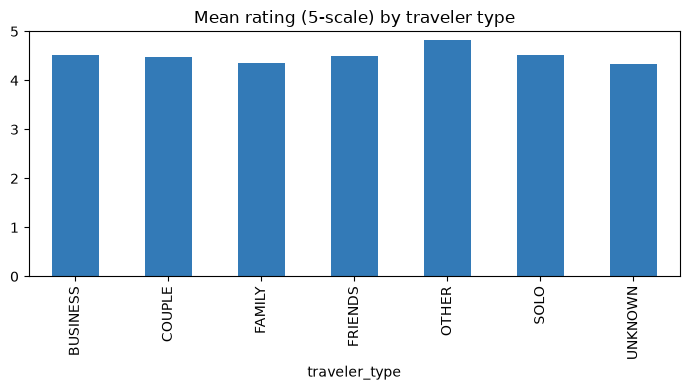

,traveler_type,n,mean,median,low_share,high_share
0,BUSINESS,74,4.510135,5.0,0.054,0.851
1,COUPLE,506,4.475692,5.0,0.069,0.858
2,FAMILY,603,4.349917,5.0,0.108,0.823
3,FRIENDS,268,4.490485,5.0,0.090,0.869
4,OTHER,6,4.833333,5.0,0.000,1.000
5,SOLO,88,4.508523,5.0,0.068,0.864
6,UNKNOWN,1468,4.328678,5.0,0.110,0.816


In [4]:

traveler_summary = clean["traveler_type"].value_counts().rename("n").to_frame()
traveler_summary["share_pct"] = (traveler_summary["n"] / len(clean) * 100).round(1)
traveler_summary.to_csv(REPO_ROOT + r"\reports\tripcom_traveler_type_summary.csv")

traveler_rating = clean.groupby("traveler_type").agg(
    n=("rating_5_scale","count"), mean=("rating_5_scale","mean"), median=("rating_5_scale","median"),
).reset_index()
low_t = clean[clean["rating_group"]=="LOW"].groupby("traveler_type").size()
high_t = clean[clean["rating_group"]=="HIGH"].groupby("traveler_type").size()
traveler_rating = traveler_rating.set_index("traveler_type")
traveler_rating["low_share"] = (low_t/traveler_rating["n"]).fillna(0).round(3)
traveler_rating["high_share"] = (high_t/traveler_rating["n"]).fillna(0).round(3)
traveler_rating = traveler_rating.reset_index()
traveler_rating.to_csv(REPO_ROOT + r"\reports\tripcom_traveler_type_rating.csv", index=False)

fig, ax = plt.subplots(figsize=(7,4))
traveler_rating.set_index("traveler_type")["mean"].plot(kind="bar", ax=ax, color="#337ab7")
ax.set_title("Mean rating (5-scale) by traveler type")
ax.set_ylim(0,5)
plt.tight_layout()
plt.savefig(FIG_DIR + r"\rating_by_traveler_type.png", dpi=110)
plt.show()
traveler_rating


### Grafik nasıl okunur?
Her çubuk bir misafir tipini (Family/Couple/Solo/Friends/vb.) ve o segmentin ortalama puanını gösterir.
### Ne görüyoruz?
Segmentler arası memnuniyet farkları (varsa).
### Neden önemli?
Otel bazlı "hangi segmentte güçlü/zayıf" analizinin temelini oluşturur.
### Dikkat edilmesi gereken nokta
UNKNOWN/OTHER segmentleri düşük güvenilirliktedir; n değerlerine dikkat edin.

## D5: Family / Couple / Solo (explicit)

In [5]:

fcs = traveler_rating[traveler_rating["traveler_type"].isin(["FAMILY","COUPLE","SOLO"])]
fcs


,traveler_type,n,mean,median,low_share,high_share
1,COUPLE,506,4.475692,5.0,0.069,0.858
2,FAMILY,603,4.349917,5.0,0.108,0.823
5,SOLO,88,4.508523,5.0,0.068,0.864


## D6: Room type x rating, x traveler type, hotel x room type

In [6]:

room_rating = clean.groupby("room_type")["rating_5_scale"].agg(["count","mean","median"])
room_rating.to_csv(REPO_ROOT + r"\reports\tripcom_room_type_summary.csv")

room_x_traveler = pd.crosstab(clean["room_type"], clean["traveler_type"])
room_x_traveler


traveler_type,BUSINESS,COUPLE,FAMILY,FRIENDS,OTHER,SOLO,UNKNOWN
room_type,,,,,,,
DELUXE,0,25,27,13,0,6,1
FAMILY,0,1,2,1,0,0,0
OTHER,5,55,32,33,0,24,5
STANDARD,1,22,21,13,2,9,2
SUITE,0,13,12,3,0,1,0
UNKNOWN,68,389,508,205,4,48,1460
VILLA,0,1,1,0,0,0,0


## D7: Reviewer country / location

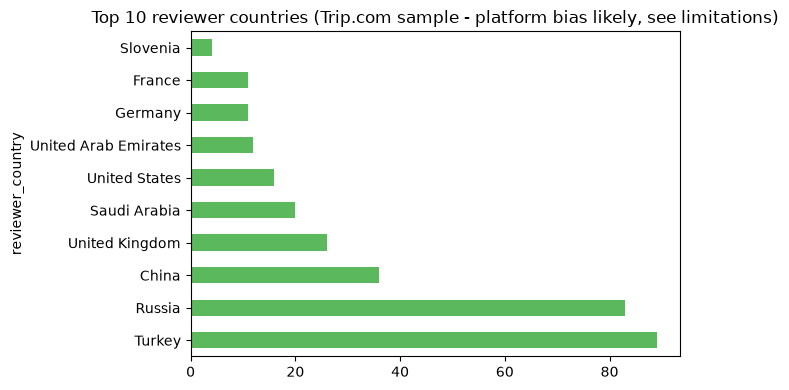

In [7]:

country_summary = clean["reviewer_country"].value_counts().rename("n").to_frame()
country_summary["share_pct"] = (country_summary["n"] / clean["reviewer_country"].notna().sum() * 100).round(1)
country_summary.to_csv(REPO_ROOT + r"\reports\tripcom_country_summary.csv")

fig, ax = plt.subplots(figsize=(7,4))
country_summary.head(10)["n"].plot(kind="barh", ax=ax, color="#5cb85c")
ax.set_title("Top 10 reviewer countries (Trip.com sample - platform bias likely, see limitations)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\top_reviewer_countries.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
En sık görülen 10 yorumcu ülkesi.
### Ne görüyoruz?
Trip.com kullanıcı tabanının coğrafi dağılımı - bu Google Travel'de mevcut olmayan bir sinyaldir.
### Neden önemli?
Hangi pazarlardan geldiğimiz konusunda fikir verir.
### Dikkat edilmesi gereken nokta
Bu, Trip.com'un kendi kullanıcı tabanının bir yansımasıdır - genel misafir evrenini temsil etmeyebilir (platform bias).

## D8: Stay month x rating x traveler

In [8]:

stay = clean.dropna(subset=["stay_month"])
if len(stay):
    stay_month_summary = stay.groupby("stay_month")["rating_5_scale"].agg(["count","mean"])
    stay_month_summary.to_csv(REPO_ROOT + r"\reports\tripcom_stay_month_summary.csv")
    stay_month_summary
else:
    print("No stay_month data yet.")


## D9: Review length vs rating

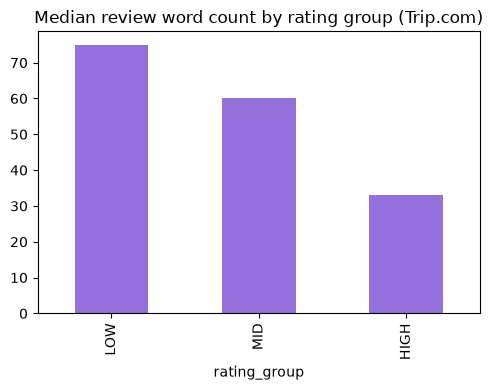

Spearman(rating_5, word_count) = -0.202 (exploratory)


In [9]:

clean["word_count"] = clean["review_text_clean"].fillna("").str.split().apply(len)
by_group = clean.groupby("rating_group")["word_count"].median()
fig, ax = plt.subplots(figsize=(5,4))
by_group.reindex(["LOW","MID","HIGH"]).plot(kind="bar", ax=ax, color="#9370db")
ax.set_title("Median review word count by rating group (Trip.com)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\review_length_vs_rating.png", dpi=110)
plt.show()

valid = clean.dropna(subset=["rating_5_scale"])
if len(valid) > 5:
    corr = valid["rating_5_scale"].corr(valid["word_count"], method="spearman")
    print("Spearman(rating_5, word_count) =", round(corr,3), "(exploratory)")


## D10: Lightweight text themes

In [10]:

import re, unicodedata
from collections import Counter

STOP = {"the","and","was","for","with","very","room","hotel","this","that","were","are","have",
        "had","not","but","from","its","our","you","they","also"}

def tokenize(t):
    if not isinstance(t, str) or not t:
        return []
    s = unicodedata.normalize("NFKD", t.lower()).encode("ascii","ignore").decode("ascii")
    words = re.findall(r"[a-z]{3,}", s)
    return [w for w in words if w not in STOP]

clean["tokens"] = clean["review_text_clean"].apply(tokenize)
term_freq = Counter(t for toks in clean["tokens"] for t in set(toks))
term_freq_df = pd.DataFrame(term_freq.most_common(20), columns=["term","document_frequency"])
term_freq_df


,term,document_frequency
0,staff,960
1,food,570
2,stay,555
3,service,549
4,great,544
5,all,523
6,beach,509
7,good,471
8,friendly,437
9,clean,437


## D11: Trip hotel profile summary

In [11]:

tt_by_hotel = clean.groupby("hotel_id")["traveler_type"].agg(lambda s: s.value_counts().idxmax() if len(s) else "UNKNOWN").rename("top_traveler_type")
family_share = clean.groupby("hotel_id")["traveler_type"].apply(lambda s: round((s=="FAMILY").mean()*100,1)).rename("family_share_pct")
couple_share = clean.groupby("hotel_id")["traveler_type"].apply(lambda s: round((s=="COUPLE").mean()*100,1)).rename("couple_share_pct")
country_cov = clean.groupby("hotel_id")["reviewer_country"].apply(lambda s: s.nunique()).rename("distinct_countries")

profile = hotel_rating.set_index("hotel_id").join([tt_by_hotel, family_share, couple_share, country_cov]).reset_index()
profile.to_csv(REPO_ROOT + r"\reports\tripcom_hotel_profile_summary.csv", index=False)
profile.head(10)


,hotel_id,hotel_name,area,n,mean_rating_5,median_rating_5,std,low_share,mid_share,high_share,sample_support,top_traveler_type,family_share_pct,couple_share_pct,distinct_countries
0,BOD002,Armonia Holiday Village & Spa,Akyarlar,11,3.818182,5.0,1.834022,0.273,0.000,0.727,LOW_SUPPORT,UNKNOWN,36.4,18.2,1
1,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,28,3.678571,4.0,1.492042,0.214,0.107,0.679,MODERATE,UNKNOWN,7.1,0.0,0
2,BOD004,Bendis Beach Hotel,Akyarlar,11,3.954545,5.0,1.556511,0.182,0.182,0.636,LOW_SUPPORT,FAMILY,36.4,18.2,2
3,BOD007,Kefaluka Resort,Akyarlar,11,4.259091,4.6,1.057549,0.091,0.091,0.818,LOW_SUPPORT,FAMILY,63.6,27.3,4
4,BOD008,LA BREZZA SUITE &HOTEL,Akyarlar,11,4.009091,5.0,1.414535,0.182,0.091,0.727,LOW_SUPPORT,UNKNOWN,0.0,9.1,0
5,BOD010,Mare Garden Hotel,Akyarlar,2,4.000000,4.0,0.000000,0.000,0.000,1.000,VERY_LOW_SUPPORT,UNKNOWN,0.0,0.0,0
6,BOD011,"Radisson Collection Hotel, Bodrum",Akyarlar,11,4.750000,5.0,0.559017,0.000,0.182,0.818,LOW_SUPPORT,COUPLE,27.3,54.5,6
7,BOD012,Selectum Collection Bodrum,Akyarlar,11,4.613636,5.0,0.944482,0.091,0.091,0.818,LOW_SUPPORT,FAMILY,81.8,0.0,2
8,BOD013,"Sentido Bellazure - Akyarlar, Bodrum / Turkey",Akyarlar,8,4.375000,5.0,1.407886,0.125,0.000,0.875,LOW_SUPPORT,FAMILY,37.5,25.0,0
9,BOD014,Suum Bodrum Hotel & Beach,Akyarlar,11,3.545455,4.0,1.752920,0.273,0.091,0.636,LOW_SUPPORT,UNKNOWN,9.1,27.3,0


## D12: Notebook 17 - Key Findings

In [12]:

findings = []
findings.append(f"Trip.com corpus covers {clean['hotel_id'].nunique()} hotels, {len(clean)} reviews.")
findings.append(f"Traveler type coverage: {kpi['traveler_type_coverage_pct']}% (raw values preserved in traveler_type_raw).")
top_seg = traveler_rating.sort_values('n', ascending=False).iloc[0]
findings.append(f"Largest traveler segment: {top_seg['traveler_type']} (n={int(top_seg['n'])}, mean={round(top_seg['mean'],2)}).")
findings.append(f"Reviewer country coverage: {kpi['reviewer_location_coverage_pct']}% - top country: "
                 f"{country_summary.index[0] if len(country_summary) else 'N/A'}.")
findings.append("Room type coverage is limited (many blanks) - room-type findings should be treated as exploratory only.")
findings.append("Stay-month seasonality analysis is limited by current sample size - see tripcom_stay_month_summary.csv.")
with open(REPO_ROOT + r"\reports\tripcom_segment_key_findings.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(f"{i+1}. {x}" for i, x in enumerate(findings)) + "\n")
for i, f_ in enumerate(findings, 1):
    print(f"{i}. {f_}")


1. Trip.com corpus covers 94 hotels, 3013 reviews.
2. Traveler type coverage: 51.3% (raw values preserved in traveler_type_raw).
3. Largest traveler segment: UNKNOWN (n=1468, mean=4.33).
4. Reviewer country coverage: 11.6% - top country: Turkey.
5. Room type coverage is limited (many blanks) - room-type findings should be treated as exploratory only.
6. Stay-month seasonality analysis is limited by current sample size - see tripcom_stay_month_summary.csv.
